<a href="https://colab.research.google.com/github/Asritha0507/ML-Market-Basket-Analysis/blob/main/12_Reorder_Timing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 12 — Reorder Timing Analysis

## Understanding When Users Are Likely to Reorder Products

This notebook analyzes the temporal behavior of users and products
to understand reorder timing in the next-basket recommendation problem.

The analysis uses historical purchase behavior and temporal features
constructed without using future information.

### Objectives

- Analyze the time between previous purchases.
- Study product-specific reorder intervals.
- Examine the relationship between purchase frequency and reorder timing.
- Identify products and users with shorter or longer reorder intervals.
- Analyze recency before the target order.
- Understand how reorder timing can support next-basket recommendations.

### Key Temporal Features

- `times_purchased_before`
- `first_purchase_before`
- `last_purchase_before`
- `recency_before`
- `purchase_span_before`
- `previous_orders`
- `days_since_prior_order`

### Research Perspective

The analysis complements the next-basket ranking model by examining
the temporal patterns behind repeat purchases. These patterns can
provide actionable insight into when a previously purchased product
may become relevant for recommendation.

In [4]:
# ============================================================
# CELL 2 — IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import os
import gc

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ============================================================
# CELL 3 — DEFINE PROJECT PATHS
# ============================================================

import os
from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/ML_Market_Basket_Analysis"
DATA_PATH = os.path.join(BASE_PATH, "Datasets")
MODEL_PATH = os.path.join(BASE_PATH, "Models", "Model_Outputs")
ENGINEERED_PATH = os.path.join(DATA_PATH, "Engineered_Features")

print("Project paths configured successfully.")
print("Engineered features path:", ENGINEERED_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project paths configured successfully.
Engineered features path: /content/drive/MyDrive/ML_Market_Basket_Analysis/Datasets/Engineered_Features


In [6]:
# ============================================================
# CELL 4 — LOAD VALIDATION DATA
# ============================================================

validation_chunks = []

for filename in sorted(os.listdir(ENGINEERED_PATH)):
    if filename.endswith(".parquet"):
        file_path = os.path.join(ENGINEERED_PATH, filename)

        chunk = pd.read_parquet(file_path)
        validation_chunk = chunk[chunk["order_number"] >= 51].copy()

        if len(validation_chunk) > 0:
            validation_chunks.append(validation_chunk)

        del chunk

validation_data = pd.concat(
    validation_chunks,
    ignore_index=True
)

print("Validation data loaded successfully.")
print("Shape:", validation_data.shape)
print("Unique target orders:", validation_data["order_id"].nunique())
print("Unique users:", validation_data["user_id"].nunique())
print("Positive rows:", validation_data["in_next_basket"].sum())

del validation_chunks
gc.collect()

Validation data loaded successfully.
Shape: (2229587, 21)
Unique target orders: 11677
Unique users: 10238
Positive rows: 106926


0

In [7]:
# ============================================================
# CELL 5 — INSPECT TEMPORAL REORDER FEATURES
# ============================================================

timing_features = [
    "times_purchased_before",
    "first_purchase_before",
    "last_purchase_before",
    "recency_before",
    "purchase_span_before",
    "previous_orders",
    "days_since_prior_order"
]

print("Temporal reorder features:\n")

print(validation_data[timing_features].describe().round(2).to_string())

print("\nMissing values:")
print(validation_data[timing_features].isnull().sum())

Temporal reorder features:

       times_purchased_before  first_purchase_before  last_purchase_before  recency_before  purchase_span_before  previous_orders  days_since_prior_order
count              2229587.00             2229587.00            2229587.00      2229587.00            2229587.00       2229587.00              2229587.00
mean                     1.53                   7.77                 13.29            7.27                  5.51            66.18                    5.62
std                      5.04                  17.11                 24.13           16.46                 15.60            15.80                    4.48
min                      0.00                   0.00                  0.00            0.00                  0.00            50.00                    0.00
25%                      0.00                   0.00                  0.00            0.00                  0.00            53.00                    3.00
50%                      0.00                   

In [8]:
# ============================================================
# CELL 6 — PREVIOUSLY PURCHASED CANDIDATES
# ============================================================

reorder_data = validation_data[
    validation_data["was_previously_purchased"] == 1
].copy()

print("Previously purchased candidate rows:", len(reorder_data))
print("Unique target orders:", reorder_data["order_id"].nunique())
print("Unique users:", reorder_data["user_id"].nunique())
print("Unique products:", reorder_data["product_id"].nunique())

print("\nPositive next-basket rows:",
      reorder_data["in_next_basket"].sum())

print("\nPositive rate:",
      round(reorder_data["in_next_basket"].mean(), 4))

Previously purchased candidate rows: 670428
Unique target orders: 11677
Unique users: 10238
Unique products: 31768

Positive next-basket rows: 101340

Positive rate: 0.1512


In [9]:
# ============================================================
# CELL 7 — REORDER TIMING COMPARISON
# ============================================================

timing_comparison = (
    reorder_data
    .groupby("in_next_basket")[
        [
            "times_purchased_before",
            "recency_before",
            "purchase_span_before"
        ]
    ]
    .mean()
    .round(2)
)

timing_comparison.index = [
    "Not Reordered",
    "Reordered"
]

print("Average historical timing features:\n")
print(timing_comparison)

Average historical timing features:

               times_purchased_before  recency_before  purchase_span_before
Not Reordered                    3.54           27.21                 14.84
Reordered                       13.84            7.06                 37.99


In [10]:
# ============================================================
# CELL 8 — REORDER RATE BY PURCHASE FREQUENCY
# ============================================================

frequency_analysis = (
    reorder_data
    .groupby("times_purchased_before")
    .agg(
        candidate_count=("product_id", "size"),
        reorder_count=("in_next_basket", "sum"),
        reorder_rate=("in_next_basket", "mean")
    )
    .reset_index()
)

frequency_analysis["reorder_rate"] = (
    frequency_analysis["reorder_rate"] * 100
).round(2)

print("Reorder rate by previous purchase frequency:\n")
print(frequency_analysis.head(20).to_string(index=False))

Reorder rate by previous purchase frequency:

 times_purchased_before  candidate_count  reorder_count  reorder_rate
                      1           290112          11438          3.94
                      2           102081           8349          8.18
                      3            56537           6781         11.99
                      4            37318           5884         15.77
                      5            26860           4993         18.59
                      6            20760           4498         21.67
                      7            16302           3949         24.22
                      8            13365           3630         27.16
                      9            11091           3288         29.65
                     10             9572           3026         31.61
                     11             8332           2929         35.15
                     12             6953           2629         37.81
                     13             6190    

In [11]:
# ============================================================
# CELL 9 — COMPLETE PURCHASE FREQUENCY RANGE
# ============================================================

print("Purchase frequency range:",
      frequency_analysis["times_purchased_before"].min(),
      "to",
      frequency_analysis["times_purchased_before"].max())

print("\nHighest observed reorder rates:")
print(
    frequency_analysis
    .sort_values("reorder_rate", ascending=False)
    .head(10)
    .to_string(index=False)
)

Purchase frequency range: 1 to 98

Highest observed reorder rates:
 times_purchased_before  candidate_count  reorder_count  reorder_rate
                     96                3              3         100.0
                     98                5              5         100.0
                     91               11             11         100.0
                     92                5              5         100.0
                     87                7              7         100.0
                     85               12             12         100.0
                     79               21             21         100.0
                     81               14             14         100.0
                     94                7              7         100.0
                     95                3              3         100.0


In [12]:
# ============================================================
# CELL 10 — BIN PURCHASE FREQUENCY
# ============================================================

reorder_data["purchase_frequency_group"] = pd.cut(
    reorder_data["times_purchased_before"],
    bins=[0, 1, 3, 5, 10, 20, 40, 60, 80, 100],
    labels=[
        "1",
        "2-3",
        "4-5",
        "6-10",
        "11-20",
        "21-40",
        "41-60",
        "61-80",
        "81-100"
    ]
)

frequency_bins = (
    reorder_data
    .groupby("purchase_frequency_group", observed=True)
    .agg(
        candidate_count=("product_id", "size"),
        reorder_count=("in_next_basket", "sum"),
        reorder_rate=("in_next_basket", "mean")
    )
    .reset_index()
)

frequency_bins["reorder_rate"] = (
    frequency_bins["reorder_rate"] * 100
).round(2)

print("Reorder rate by purchase-frequency group:\n")
print(frequency_bins.to_string(index=False))

Reorder rate by purchase-frequency group:

purchase_frequency_group  candidate_count  reorder_count  reorder_rate
                       1           290112          11438          3.94
                     2-3           158618          15130          9.54
                     4-5            64178          10877         16.95
                    6-10            71090          18391         25.87
                   11-20            50063          20954         41.86
                   21-40            28863          18253         63.24
                   41-60             6411           5319         82.97
                   61-80              937            833         88.90
                  81-100              156            145         92.95


In [13]:
# ============================================================
# CELL 11 — REORDER RATE BY RECENCY
# ============================================================

reorder_data["recency_group"] = pd.cut(
    reorder_data["recency_before"],
    bins=[-1, 1, 3, 7, 14, 30, 60, 100],
    labels=[
        "0-1",
        "2-3",
        "4-7",
        "8-14",
        "15-30",
        "31-60",
        "61-100"
    ]
)

recency_analysis = (
    reorder_data
    .groupby("recency_group", observed=True)
    .agg(
        candidate_count=("product_id", "size"),
        reorder_count=("in_next_basket", "sum"),
        reorder_rate=("in_next_basket", "mean")
    )
    .reset_index()
)

recency_analysis["reorder_rate"] = (
    recency_analysis["reorder_rate"] * 100
).round(2)

print("Reorder rate by recency group:\n")
print(recency_analysis.to_string(index=False))

Reorder rate by recency group:

recency_group  candidate_count  reorder_count  reorder_rate
          0-1            61077          32044         52.46
          2-3            71388          27378         38.35
          4-7            82515          18456         22.37
         8-14            92132          10532         11.43
        15-30           135690           7497          5.53
        31-60           175707           4558          2.59
       61-100            51919            875          1.69


In [14]:
# ============================================================
# CELL 12 — REORDER RATE BY PURCHASE SPAN
# ============================================================

reorder_data["purchase_span_group"] = pd.cut(
    reorder_data["purchase_span_before"],
    bins=[-1, 0, 3, 7, 14, 30, 60, 100],
    labels=[
        "0",
        "1-3",
        "4-7",
        "8-14",
        "15-30",
        "31-60",
        "61-100"
    ]
)

span_analysis = (
    reorder_data
    .groupby("purchase_span_group", observed=True)
    .agg(
        candidate_count=("product_id", "size"),
        reorder_count=("in_next_basket", "sum"),
        reorder_rate=("in_next_basket", "mean")
    )
    .reset_index()
)

span_analysis["reorder_rate"] = (
    span_analysis["reorder_rate"] * 100
).round(2)

print("Reorder rate by purchase-span group:\n")
print(span_analysis.to_string(index=False))

Reorder rate by purchase-span group:

purchase_span_group  candidate_count  reorder_count  reorder_rate
                  0           290112          11438          3.94
                1-3            33599           3831         11.40
                4-7            33655           4317         12.83
               8-14            47335           7076         14.95
              15-30            81364          13621         16.74
              31-60           135707          41538         30.61
             61-100            48656          19519         40.12


In [15]:
# ============================================================
# CELL 13 — REORDER RATE BY DAYS SINCE PRIOR ORDER
# ============================================================

reorder_data["order_gap_group"] = pd.cut(
    reorder_data["days_since_prior_order"],
    bins=[-1, 3, 7, 14, 21, 30],
    labels=[
        "0-3 days",
        "4-7 days",
        "8-14 days",
        "15-21 days",
        "22-30 days"
    ]
)

order_gap_analysis = (
    reorder_data
    .groupby("order_gap_group", observed=True)
    .agg(
        candidate_count=("product_id", "size"),
        reorder_count=("in_next_basket", "sum"),
        reorder_rate=("in_next_basket", "mean")
    )
    .reset_index()
)

order_gap_analysis["reorder_rate"] = (
    order_gap_analysis["reorder_rate"] * 100
).round(2)

print("Reorder rate by days since prior order:\n")
print(order_gap_analysis.to_string(index=False))

Reorder rate by days since prior order:

order_gap_group  candidate_count  reorder_count  reorder_rate
       0-3 days           233089          34669         14.87
       4-7 days           302521          46088         15.23
      8-14 days           105856          16097         15.21
     15-21 days            19483           2976         15.27
     22-30 days             9479           1510         15.93


In [16]:
# ============================================================
# CELL 14 — TIMING ANALYSIS SUMMARY
# ============================================================

timing_summary = pd.DataFrame({
    "Analysis": [
        "Purchase Frequency",
        "Recency Before Target",
        "Purchase Span",
        "Days Since Prior Order"
    ],
    "Observation": [
        "Higher previous purchase frequency is associated with higher reorder rate.",
        "More recent previous purchases are associated with higher reorder rate.",
        "Longer purchase history span is associated with higher reorder rate.",
        "Overall order gap shows only small variation in reorder rate."
    ]
})

print("Reorder Timing Analysis Summary:\n")
print(timing_summary.to_string(index=False))

Reorder Timing Analysis Summary:

              Analysis                                                                Observation
    Purchase Frequency Higher previous purchase frequency is associated with higher reorder rate.
 Recency Before Target    More recent previous purchases are associated with higher reorder rate.
         Purchase Span       Longer purchase history span is associated with higher reorder rate.
Days Since Prior Order              Overall order gap shows only small variation in reorder rate.


In [17]:
# ============================================================
# CELL 15 — SAVE TIMING SUMMARY
# ============================================================

timing_summary_path = os.path.join(
    MODEL_PATH,
    "reorder_timing_summary.csv"
)

timing_summary.to_csv(timing_summary_path, index=False)

print("Timing summary saved successfully.")
print("File:", timing_summary_path)
print("Shape:", timing_summary.shape)

Timing summary saved successfully.
File: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/reorder_timing_summary.csv
Shape: (4, 2)


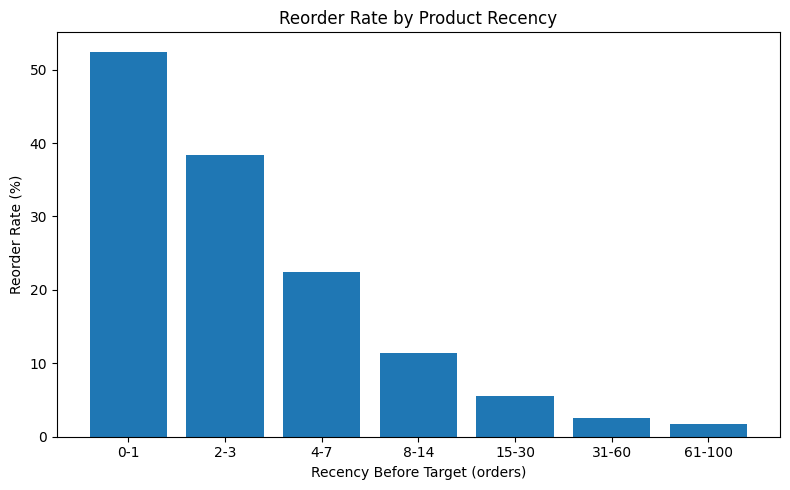

In [18]:
# ============================================================
# CELL 16 — REORDER RATE BY RECENCY
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    recency_analysis["recency_group"].astype(str),
    recency_analysis["reorder_rate"]
)

plt.xlabel("Recency Before Target (orders)")
plt.ylabel("Reorder Rate (%)")
plt.title("Reorder Rate by Product Recency")

plt.tight_layout()
plt.show()

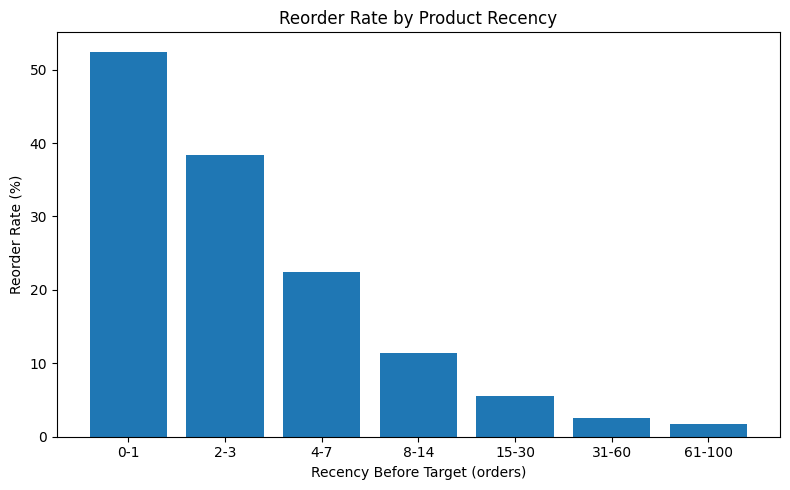

Recency plot saved successfully.
File: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/reorder_rate_by_recency.png


In [19]:
# ============================================================
# CELL 17 — SAVE RECENCY PLOT
# ============================================================

recency_plot_path = os.path.join(
    MODEL_PATH,
    "reorder_rate_by_recency.png"
)

plt.figure(figsize=(8, 5))

plt.bar(
    recency_analysis["recency_group"].astype(str),
    recency_analysis["reorder_rate"]
)

plt.xlabel("Recency Before Target (orders)")
plt.ylabel("Reorder Rate (%)")
plt.title("Reorder Rate by Product Recency")

plt.tight_layout()
plt.savefig(recency_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Recency plot saved successfully.")
print("File:", recency_plot_path)

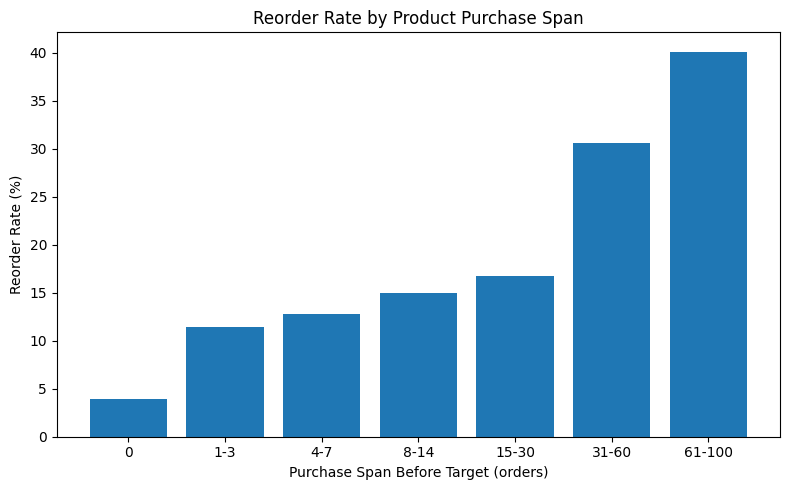

In [20]:
# ============================================================
# CELL 18 — REORDER RATE BY PURCHASE SPAN
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    span_analysis["purchase_span_group"].astype(str),
    span_analysis["reorder_rate"]
)

plt.xlabel("Purchase Span Before Target (orders)")
plt.ylabel("Reorder Rate (%)")
plt.title("Reorder Rate by Product Purchase Span")

plt.tight_layout()
plt.show()

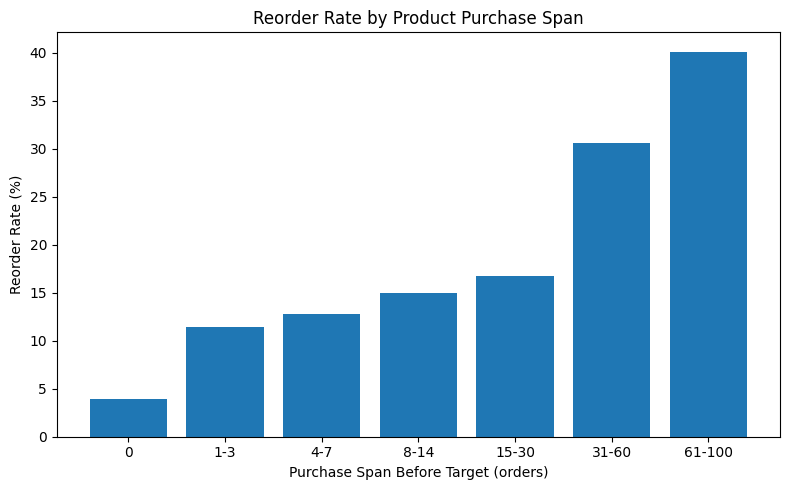

Purchase-span plot saved successfully.
File: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/reorder_rate_by_purchase_span.png


In [21]:
# ============================================================
# CELL 19 — SAVE PURCHASE-SPAN PLOT
# ============================================================

span_plot_path = os.path.join(
    MODEL_PATH,
    "reorder_rate_by_purchase_span.png"
)

plt.figure(figsize=(8, 5))

plt.bar(
    span_analysis["purchase_span_group"].astype(str),
    span_analysis["reorder_rate"]
)

plt.xlabel("Purchase Span Before Target (orders)")
plt.ylabel("Reorder Rate (%)")
plt.title("Reorder Rate by Product Purchase Span")

plt.tight_layout()
plt.savefig(span_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Purchase-span plot saved successfully.")
print("File:", span_plot_path)

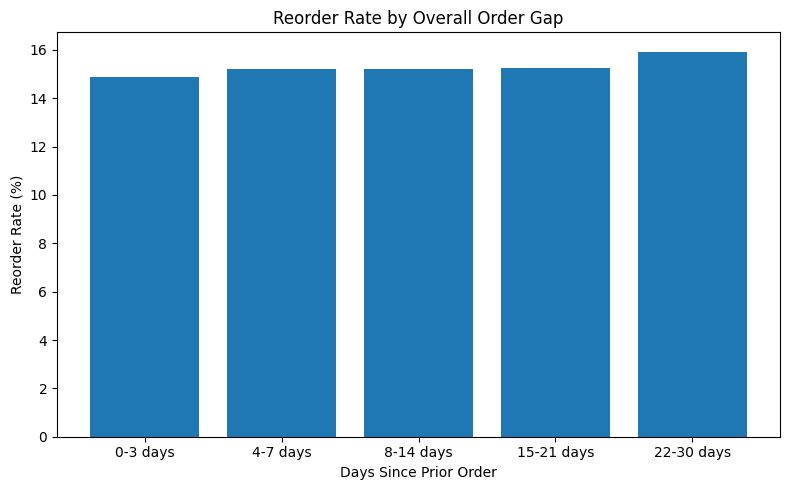

In [22]:
# ============================================================
# CELL 20 — REORDER RATE BY DAYS SINCE PRIOR ORDER
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    order_gap_analysis["order_gap_group"].astype(str),
    order_gap_analysis["reorder_rate"]
)

plt.xlabel("Days Since Prior Order")
plt.ylabel("Reorder Rate (%)")
plt.title("Reorder Rate by Overall Order Gap")

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# CELL 21 — SAVE ORDER-GAP PLOT
# ============================================================

order_gap_plot_path = os.path.join(
    MODEL_PATH,
    "reorder_rate_by_order_gap.png"
)

plt.savefig(order_gap_plot_path, dpi=300, bbox_inches="tight")

print("Order-gap plot saved successfully.")
print("File:", order_gap_plot_path)

Order-gap plot saved successfully.
File: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/reorder_rate_by_order_gap.png


<Figure size 640x480 with 0 Axes>

In [24]:
# ============================================================
# CELL 22 — REGENERATE AND SAVE ORDER-GAP PLOT
# ============================================================

order_gap_plot_path = os.path.join(
    MODEL_PATH,
    "reorder_rate_by_order_gap.png"
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    order_gap_analysis["order_gap_group"].astype(str),
    order_gap_analysis["reorder_rate"]
)

ax.set_xlabel("Days Since Prior Order")
ax.set_ylabel("Reorder Rate (%)")
ax.set_title("Reorder Rate by Overall Order Gap")

fig.tight_layout()
fig.savefig(order_gap_plot_path, dpi=300, bbox_inches="tight")
plt.close(fig)

print("Order-gap plot saved successfully.")
print("File:", order_gap_plot_path)

Order-gap plot saved successfully.
File: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/reorder_rate_by_order_gap.png


In [25]:
# ============================================================
# CELL 23 — SAVE NUMERICAL TIMING ANALYSES
# ============================================================

frequency_path = os.path.join(
    MODEL_PATH,
    "reorder_rate_by_purchase_frequency.csv"
)

recency_path = os.path.join(
    MODEL_PATH,
    "reorder_rate_by_recency.csv"
)

span_path = os.path.join(
    MODEL_PATH,
    "reorder_rate_by_purchase_span.csv"
)

order_gap_path = os.path.join(
    MODEL_PATH,
    "reorder_rate_by_order_gap.csv"
)

frequency_bins.to_csv(frequency_path, index=False)
recency_analysis.to_csv(recency_path, index=False)
span_analysis.to_csv(span_path, index=False)
order_gap_analysis.to_csv(order_gap_path, index=False)

print("Timing analysis tables saved successfully.")
print("\nSaved files:")
print(frequency_path)
print(recency_path)
print(span_path)
print(order_gap_path)

Timing analysis tables saved successfully.

Saved files:
/content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/reorder_rate_by_purchase_frequency.csv
/content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/reorder_rate_by_recency.csv
/content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/reorder_rate_by_purchase_span.csv
/content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/reorder_rate_by_order_gap.csv


# Final Reorder Timing Findings

The reorder timing analysis shows several clear patterns in the validation data:

1. **Purchase Frequency**
   Products with a higher number of previous purchases show higher observed
   reorder rates. The rate increases from 3.94% for products purchased once
   previously to 92.95% for the 81–100 purchase-frequency group.

2. **Recency Before Target**
   Recency shows a strong inverse relationship with reorder rate. Products
   purchased more recently are more frequently reordered. The reorder rate
   decreases from 52.46% for recency 0–1 orders to 1.69% for recency 61–100
   orders.

3. **Purchase Span**
   Products with a longer historical purchase span show higher observed
   reorder rates. The rate increases from 3.94% for zero purchase span to
   40.12% for the 61–100 order span.

4. **Days Since Prior Order**
   The overall gap between consecutive user orders shows only small variation
   in reorder rate. The rates remain approximately between 14.87% and 15.93%
   across the analyzed order-gap groups.

## Overall Interpretation

The results indicate that product-level historical behavior, particularly
purchase frequency, recency, and purchase span, provides useful temporal
signals for understanding repeat-purchase behavior.

The overall user order gap alone shows a much weaker observed relationship
with whether a previously purchased product appears in the next basket.

These findings complement the temporal XGBoost ranking model by providing
business-level insight into the temporal patterns associated with repeat
purchases.

These results represent observed associations in the validation data and
should not be interpreted as causal relationships.

In [26]:
# ============================================================
# CELL 25 — FINAL VERIFICATION
# ============================================================

verification_files = [
    "reorder_timing_summary.csv",
    "reorder_rate_by_purchase_frequency.csv",
    "reorder_rate_by_recency.csv",
    "reorder_rate_by_purchase_span.csv",
    "reorder_rate_by_order_gap.csv",
    "reorder_rate_by_recency.png",
    "reorder_rate_by_purchase_span.png",
    "reorder_rate_by_order_gap.png"
]

print("Notebook 12 — Final Verification\n")

for filename in verification_files:
    path = os.path.join(MODEL_PATH, filename)
    print(f"{filename}: {'FOUND' if os.path.exists(path) else 'MISSING'}")

print("\nTable shapes:")
print("Timing summary:", timing_summary.shape)
print("Frequency groups:", frequency_bins.shape)
print("Recency groups:", recency_analysis.shape)
print("Purchase-span groups:", span_analysis.shape)
print("Order-gap groups:", order_gap_analysis.shape)

print("\nNotebook 12 verification completed.")

Notebook 12 — Final Verification

reorder_timing_summary.csv: FOUND
reorder_rate_by_purchase_frequency.csv: FOUND
reorder_rate_by_recency.csv: FOUND
reorder_rate_by_purchase_span.csv: FOUND
reorder_rate_by_order_gap.csv: FOUND
reorder_rate_by_recency.png: FOUND
reorder_rate_by_purchase_span.png: FOUND
reorder_rate_by_order_gap.png: FOUND

Table shapes:
Timing summary: (4, 2)
Frequency groups: (9, 4)
Recency groups: (7, 4)
Purchase-span groups: (7, 4)
Order-gap groups: (5, 4)

Notebook 12 verification completed.
